In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import textwrap

from pathlib import Path
from typing import Optional
from tqdm import tqdm

plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 11
})

PSEUDO = 1e-300

In [ ]:
# ── DATA DIRECTORY ──────────────────────────────────────────────────────────
# Update this path if you cloned the repo to a different location.
# In WSL, your OneDrive Documents typically maps to:
DATA_DIR = "/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22"
DESEQ2_DIR = f"{DATA_DIR}/DeSeq2"
TPM_DIR    = f"{DATA_DIR}/Arquivos brutos/TPM"
GENOME_DIR = f"{DATA_DIR}/Arquivos brutos/genomes_9a5c_temecula1"


In [18]:
import sys
from pathlib import Path

sys.path.append(str(Path("Gene_Ontology_2nd_Level")))

In [24]:
from go_to_2nd import get_ancestors

The file  -f not exists


SystemExit: 

In [25]:
%tb

/mnt/c/Users/oseia/OneDrive/Documents/OLD_FILE_TO_ORGANIZE/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2/DESeq2_results/Gene_Ontology_2nd_Level/go_to_2nd.py:78: SyntaxWarning: invalid escape sequence '\d'
  raw_string_gos = re.findall('GO:(\d+)',string)
/mnt/c/Users/oseia/OneDrive/Documents/OLD_FILE_TO_ORGANIZE/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2/DESeq2_results/Gene_Ontology_2nd_Level/go_to_2nd.py:92: SyntaxWarning: invalid escape sequence '\s'
  term = re.findall(':\s*([^.]+|\S+)',i)


SystemExit: 

In [23]:
import Gene_Ontology_2nd_Level as go2

print(dir(go2))

['__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__']


In [2]:
cd /mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2/DESeq2_results

/mnt/c/Users/oseia/OneDrive/Documents/OLD_FILE_TO_ORGANIZE/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2/DESeq2_results


In [26]:
# Cell 2 — Paths & global parameters
# Working directory with your 24 .txt files (change if needed)
# WORKDIR = Path("/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2")  # <- update to your folder
WORKDIR = Path("/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/DeSeq2")
OUTDIR = WORKDIR / "DESeq2_results"
OUTDIR.mkdir(parents=True, exist_ok=True)
FORMATTED_SUMMARY = OUTDIR / "formatted_summary.csv"

# GO_SUFFIX = "GO_enrichment"
# OUTPUT_SUFFIX = "paired_bubble"

# label_top_n = 10
# size_scale = 1200  # tweak to increase/decrease bubble sizes
# cmap_name = 'viridis'  # colormap for p-values

# OUTDIR = WORKDIR / "DESeq2_results"
# FORMATTED_SUMMARY = OUTDIR / "formatted_summary.csv"

In [27]:
# Cell 3 — Condition → phase mapping (authoritative)

_PHASE_RULES = {
    ("9a5c", "PIM6", "1d"): "early phase",
    ("9a5c", "PIM6", "3d"): "late phase",
    ("9a5c", "PWG", "3d"): "early phase",
    ("9a5c", "PWG", "10d"): "late phase",
    ("Temecula1", "PIM6", "1d"): "early phase",
    ("Temecula1", "PIM6", "3d"): "late phase",
    ("Temecula1", "PWG", "3d"): "early phase",
    ("Temecula1", "PWG", "7d"): "late phase",
}

def format_condition_label(cond: str) -> str:
    parts = cond.split("_")
    if len(parts) < 3:
        return cond.replace("_", " – ")
    strain, medium, time = parts[0], parts[1], parts[2]
    phase = _PHASE_RULES.get((strain, medium, time), time)
    return f"{strain} – {medium} – {phase}"

In [5]:
# Cell 4 — QuickGO utilities

# @lru_cache(maxsize=1024)
# def quickgo_get_ancestors(go_id):
#     try:
#         gid = go_id.replace(":", "%3A")
#         url = f"https://www.ebi.ac.uk/QuickGO/services/ontology/go/terms/{gid}/ancestors"
#         r = requests.get(url, headers={"Accept": "application/json"}, timeout=10)
#         if not r.ok:
#             return set()
#         data = r.json().get("results", [])
#         ancestors = set()
#         for item in data:
#             ancestors.update(item.get("ancestors", []))
#         return ancestors
#     except Exception:
#         return set()

In [6]:
# # Cell 5 — GO deduplication

# def dedupe_go_by_ancestor(df, p_adj_col='p_adj', go_col='go_term'):
#     df = df.copy().reset_index(drop=True)
#     terms = df[go_col].unique()
#     ancestors = {g: quickgo_get_ancestors(g) for g in terms}
#     keep = {g: True for g in terms}

#     for i, a in enumerate(terms):
#         for b in terms[i+1:]:
#             if not (keep[a] and keep[b]):
#                 continue
#             if a in ancestors[b] or b in ancestors[a]:
#                 pa = df.loc[df[go_col] == a, p_adj_col].min()
#                 pb = df.loc[df[go_col] == b, p_adj_col].min()
#                 if pa <= pb:
#                     keep[b] = False
#                 else:
#                     keep[a] = False

#     return df[df[go_col].isin([k for k, v in keep.items() if v])]

In [34]:
# Cell 6 — GO enrichment file I/O utilities
def find_go_enrichment_file(comp_out: Path, condition_name: str) -> Optional[Path]:
    if not comp_out.exists():
        return None
    candidates = sorted(comp_out.glob(f"GO_enrichment*{condition_name}*.csv"))
    if candidates:
        return candidates[0]
    candidates = sorted(comp_out.glob("GO_enrichment_*.csv"))
    if candidates:
        return candidates[0]
    return None


def load_go_df(path: Optional[Path]) -> pd.DataFrame:
    if path is None or not Path(path).exists():
        return pd.DataFrame(
            columns=['go_term','go_description','fold_enrichment','p_adj','deg_count','bg_count']
        )

    df = pd.read_csv(path)

    out = pd.DataFrame()

    # --- GO ID ---
    go_col = next((c for c in df.columns if 'go' in c.lower()), None)
    if go_col is None:
        return pd.DataFrame()  # skip broken file safely

    out['go_term'] = df[go_col].astype(str)

    # --- Description ---
    desc_col = next((c for c in df.columns if 'desc' in c.lower() or 'name' in c.lower()), None)
    if desc_col:
        out['go_description'] = df[desc_col].astype(str)
    else:
        out['go_description'] = out['go_term']

    # --- Helper ---
    def safe_numeric(colnames, default=0.0):
        col = next((c for c in colnames if c in df.columns), None)
        if col:
            return pd.to_numeric(df[col], errors='coerce').fillna(default)
        else:
            return pd.Series([default] * len(df))

    # --- Numeric columns (SAFE) ---
    out['fold_enrichment'] = safe_numeric(['fold_enrichment','fold','odds_ratio'], default=0.0)
    out['p_adj'] = safe_numeric(['p_adj','padj','p.adjust','p_value'], default=1.0)
    out['deg_count'] = safe_numeric(['deg_count','count','deg'], default=0).astype(int)

    # --- GO class (BP/MF/CC if present) ---
    ont_col = next((c for c in df.columns if 'ontology' in c.lower()), None)
    if ont_col:
        out['GO_class'] = df[ont_col]
    else:
        out['GO_class'] = "BP"  # fallback

    out['bg_count'] = 0

    return out

In [8]:
# # Cell 7 — Merge GO tables

# def merge_go_tables(df1, df2):
#     merged = pd.merge(df1, df2, on="go_term", how="outer")
#     merged["p_avg"] = (merged["p_adj_c1"] + merged["p_adj_c2"]) / 2
#     return merged

In [8]:
# # Cell 8 — Label helpers

# def clamp(val, vmin, vmax):
#     return max(vmin, min(val, vmax))

# def clamp_point(x, y, xlim, ylim, frac=0.03):
#     dx = frac * (xlim[1] - xlim[0])
#     dy = frac * (ylim[1] - ylim[0])
#     return (
#         clamp(x, xlim[0] + dx, xlim[1] - dx),
#         clamp(y, ylim[0] + dy, ylim[1] - dy)
#     )

In [9]:
# # Cell 9 — External colorbar

# def add_colorbar_outside(fig, ax, mappable, label):
#     pos = ax.get_position()
#     cax = fig.add_axes([
#         pos.x1 + 0.05,
#         pos.y0 + 0.2 * pos.height,
#         0.025,
#         0.6 * pos.height
#     ])
#     cbar = fig.colorbar(mappable, cax=cax)
#     cbar.set_label(label)
#     return cbar

In [35]:
# Cell 10 — Build comparison list (single source of truth)

from pathlib import Path

c1_col = "Condition 1 (c1)"
c2_col = "Condition 2 (c2)"

comparisons = []

# Preferred: load from formatted summary if it exists
if FORMATTED_SUMMARY.exists():
    fs = pd.read_csv(FORMATTED_SUMMARY)

    # robust column detection
    c1_col = next((c for c in fs.columns if "Condition 1" in c), c1_col)
    c2_col = next((c for c in fs.columns if "Condition 2" in c), c2_col)

    comparisons = fs[[c1_col, c2_col]].to_dict(orient="records")

else:
    # Fallback: infer from OUTDIR folder names
    for p in sorted(OUTDIR.iterdir()):
        if p.is_dir() and "_vs_" in p.name:
            c1, c2 = p.name.split("_vs_", 1)
            comparisons.append({
                c1_col: c1,
                c2_col: c2
            })

print(f"Loaded {len(comparisons)} comparisons")

Loaded 12 comparisons


In [36]:
# Cell 11 — Final paired GO bubble plot

GO_DICT_PATH = Path("dictionary_2_level.csv")

go_dict_df = pd.read_csv(GO_DICT_PATH, header=None)
go_dict_df = go_dict_df[go_dict_df[4] == "is_a"]

GO_TO_LEVEL2 = dict(zip(go_dict_df[2], go_dict_df[3]))

def map_to_level2(go_id: str) -> str:
    return GO_TO_LEVEL2.get(go_id, go_id)


# def plot_paired_bubble_final(
#     df: pd.DataFrame,
#     comp_out: Path,
#     c1: str,
#     c2: str,
#     max_terms: int = 8,
#     label_top_n: int = 8,
#     size_scale: int = 1400,
#     cmap_name: str = "viridis",
#     jitter_frac: float = 0.02,
#     dpi: int = 600,
# ):
#     """
#     Final publication-ready paired GO bubble plot.
#     Fixes:
#     - axis label duplication
#     - label overlap & clipping
#     - colorbar overlap
#     - single-bubble edge cases
#     """

#     if df is None or df.empty:
#         return None

#     # ---- rank & subset terms ----
#     df = df.copy()
#     df["p_avg"] = (df["p_adj_c1"] + df["p_adj_c2"]) / 2
#     df = df.sort_values("p_avg", ascending=True)

#     if max_terms:
#         df = df.head(max_terms)

#     # ---- extract values ----
#     x = df["fold_enrichment_c1"].to_numpy(dtype=float)
#     y = df["fold_enrichment_c2"].to_numpy(dtype=float)
#     p1 = df["p_adj_c1"].to_numpy(dtype=float)
#     p2 = df["p_adj_c2"].to_numpy(dtype=float)

#     sig_best = -np.log10(np.minimum(p1, p2) + PSEUDO)
#     sig_avg = -np.log10((p1 + p2) / 2 + PSEUDO)

#     # ---- bubble aesthetics ----
#     sizes = (sig_best / sig_best.max() if sig_best.max() > 0 else 1.0) * size_scale
#     sizes = np.clip(sizes, 40, None)

#     cmap = plt.get_cmap(cmap_name)
#     norm = Normalize(vmin=0, vmax=max(1.0, sig_avg.max()))

#     # ---- jitter (safe for single-point plots) ----
#     if len(x) > 1:
#         xr = max(x.max() - x.min(), 1e-6)
#         yr = max(y.max() - y.min(), 1e-6)
#         rng = np.random.default_rng(42)
#         x = x + rng.normal(0, jitter_frac * xr, size=len(x))
#         y = y + rng.normal(0, jitter_frac * yr, size=len(y))

#     # ---- axis limits (ALLOW negative if needed) ----
#     xmin, xmax = x.min(), x.max()
#     ymin, ymax = y.min(), y.max()

#     if xmax - xmin < 1e-6:
#         xmin -= 0.5
#         xmax += 0.5
#     if ymax - ymin < 1e-6:
#         ymin -= 0.5
#         ymax += 0.5

#     pad_x = 0.12 * (xmax - xmin)
#     pad_y = 0.12 * (ymax - ymin)

#     xlim = (xmin - pad_x, xmax + pad_x)
#     ylim = (ymin - pad_y, ymax + pad_y)

#     # ---- figure ----
#     fig, ax = plt.subplots(figsize=(7, 7))
#     ax.grid(True, linestyle="--", linewidth=0.4, alpha=0.4, zorder=0)

#     sc = ax.scatter(
#         x, y,
#         s=sizes,
#         c=sig_avg,
#         cmap=cmap,
#         norm=norm,
#         edgecolor="black",
#         linewidth=0.4,
#         alpha=0.88,
#         zorder=3,
#         clip_on=False
#     )

#     # ---- identity line ----
#     lo = min(xlim[0], ylim[0])
#     hi = max(xlim[1], ylim[1])
#     ax.plot([lo, hi], [lo, hi], "--", color="gray", linewidth=0.8, zorder=1)

#     # ---- labels: CLAMPED + NON-OVERLAPPING ----
#     label_n = min(label_top_n, len(df))
#     if label_n > 0:
#         label_df = df.head(label_n)
#         lx = x[:label_n].copy()
#         ly = y[:label_n].copy()

#         # vertical repulsion
#         order = np.argsort(ly)
#         ly_sorted = ly[order]
#         min_sep = 0.05 * (ylim[1] - ylim[0])

#         for i in range(1, len(ly_sorted)):
#             if ly_sorted[i] - ly_sorted[i-1] < min_sep:
#                 ly_sorted[i] = ly_sorted[i-1] + min_sep

#         ly[order] = ly_sorted

#         for i, row in enumerate(label_df.itertuples()):
#             tx, ty = clamp_point(
#                 lx[i] + 0.015 * (xlim[1] - xlim[0]),
#                 ly[i],
#                 xlim, ylim
#             )
#             ax.text(
#                 tx, ty,
#                 textwrap.fill(row.go_description, 36),
#                 fontsize=8,
#                 zorder=4,
#                 clip_on=False,
#                 bbox=dict(facecolor="white", alpha=0.82, edgecolor="none", pad=1)
#             )

#     # ---- axis labels (FIXED) ----
#     ax.set_xlabel(f"{format_condition_label(c1)} (fold enrichment)")
#     ax.set_ylabel(f"{format_condition_label(c2)} (fold enrichment)")

#     ax.set_xlim(xlim)
#     ax.set_ylim(ylim)
#     # ax.set_aspect("equal", adjustable="box") # DO NOT force equal aspect for GO enrichment plots

#     # ---- colorbar (ALWAYS OUTSIDE) ----
#     add_colorbar_outside(fig, ax, sc, label="-log10(avg adjusted p-value)")

#     # ---- save ----
#     comp_out.mkdir(parents=True, exist_ok=True)
#     outpath = comp_out / f"paired_bubble_{comp_out.name}.tiff"
#     fig.savefig(outpath, dpi=dpi, bbox_inches="tight")
#     plt.close(fig)

#     return outpath

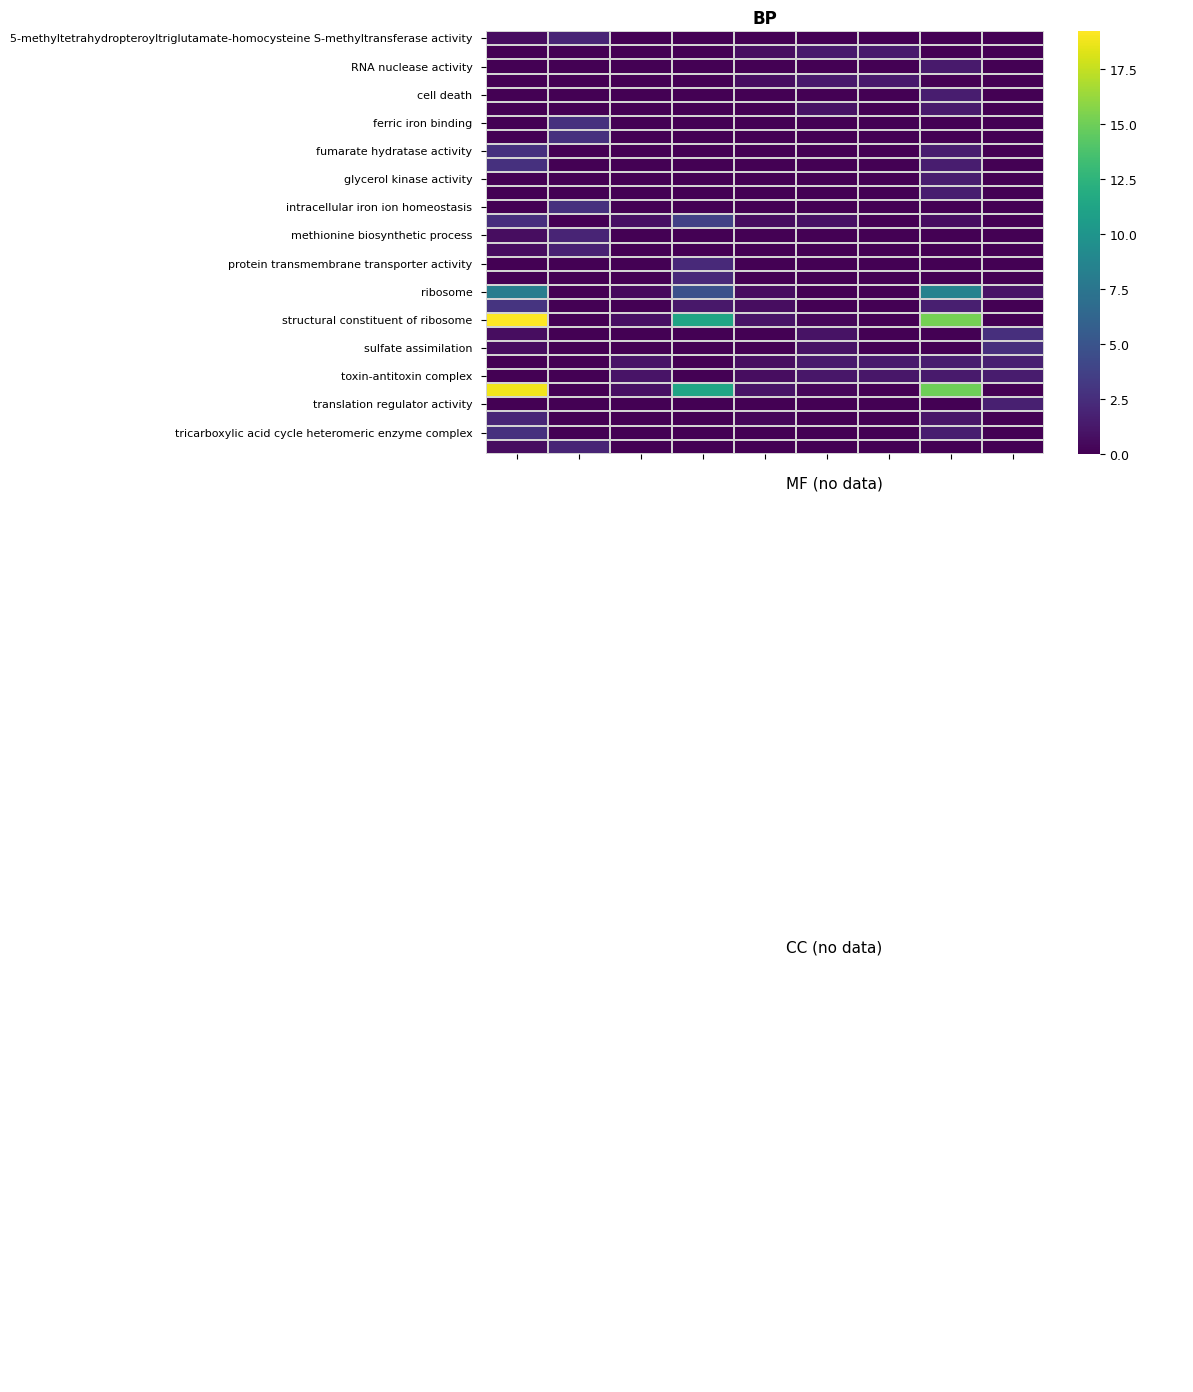

In [37]:
# Cell 12 — GO heatmap (stacked BP / MF / CC)

def build_go_heatmap_matrix(comparisons):
    records = []

    for rec in comparisons:
        try:
            c1 = rec[c1_col]
            c2 = rec[c2_col]
            comp_name = f"{c1}_vs_{c2}"
            comp_out = OUTDIR / comp_name

            if not comp_out.exists():
                continue

            f1 = find_go_enrichment_file(comp_out, c1)
            f2 = find_go_enrichment_file(comp_out, c2)

            df1 = load_go_df(f1)
            df2 = load_go_df(f2)

            if df1.empty and df2.empty:
                continue

            # rename
            df1 = df1.rename(columns={
                "fold_enrichment": "fold_enrichment_c1",
                "p_adj": "p_adj_c1"
            })
            df2 = df2.rename(columns={
                "fold_enrichment": "fold_enrichment_c2",
                "p_adj": "p_adj_c2"
            })

            merged = pd.merge(df1, df2, on="go_term", how="outer")

            # descriptions
            merged["go_description"] = merged.get("go_description_x").combine_first(
                merged.get("go_description_y")
            ).fillna(merged["go_term"])

            # class (if missing → BP fallback)
            if "GO_class_x" in merged.columns:
                merged["GO_class"] = merged["GO_class_x"].fillna(merged.get("GO_class_y"))
            else:
                merged["GO_class"] = "BP"

            # significance score
            merged["p_adj"] = merged[["p_adj_c1", "p_adj_c2"]].min(axis=1)
            merged["score"] = -np.log10(merged["p_adj"] + PSEUDO)

            for _, row in merged.iterrows():
                records.append({
                    "GO": row["go_description"],
                    "GO_class": row["GO_class"],
                    "comparison": comp_name,
                    "score": row["score"]
                })

        except Exception as e:
            tqdm.write(f"Skipping {comp_name}: {e}")

    return pd.DataFrame(records)


def plot_stacked_go_heatmaps(df, top_n=25):

    if df.empty:
        print("No GO data available")
        return

    # clean descriptions (remove [IEA] etc.)
    df["GO"] = df["GO"].str.replace(r"\[.*?\]", "", regex=True)

    # global ranking
    ranking = (
        df.groupby("GO")["score"]
        .mean()
        .sort_values(ascending=False)
        .head(top_n)
        .index
    )

    df = df[df["GO"].isin(ranking)]

    classes = ["BP", "MF", "CC"]

    fig, axes = plt.subplots(
        nrows=3, ncols=1,
        figsize=(12, 14),
        sharex=True
    )

    for ax, go_class in zip(axes, classes):

        subset = df[df["GO_class"] == go_class]

        if subset.empty:
            ax.set_title(f"{go_class} (no data)")
            ax.axis("off")
            continue

        pivot = subset.pivot_table(
            index="GO",
            columns="comparison",
            values="score",
            aggfunc="mean"
        ).fillna(0)

        sns.heatmap(
            pivot,
            ax=ax,
            cmap="viridis",
            linewidths=0.2,
            linecolor="lightgray",
            cbar=ax == axes[0],  # single colorbar
        )

        ax.set_title(go_class, fontsize=12, weight="bold")
        ax.set_ylabel("")
        ax.set_xlabel("")

        ax.tick_params(axis='y', labelsize=8)
        ax.tick_params(axis='x', labelrotation=45)

    plt.tight_layout()
    plt.show()


# ---- RUN ----
go_df = build_go_heatmap_matrix(comparisons)
plot_stacked_go_heatmaps(go_df, top_n=30)

# TEST_COMPARISONS = {
#     "9a5c_PIM6_1d_vs_9a5c_PIM6_3d",
#     "9a5c_PWG_10d_vs_Temecula1_PWG_7d",
#     # "9a5c_PIM6_1d_vs_Temecula1_PIM6_1d",  # optional
# }

# for rec in comparisons:
#     try:
#         # extract conditions FIRST
#         c1 = rec[c1_col]
#         c2 = rec[c2_col]

#         comp_name = f"{c1}_vs_{c2}"

#         # 🔒 TEST FILTER
#         if comp_name not in TEST_COMPARISONS:
#             continue

#         comp_out = OUTDIR / comp_name
#         if not comp_out.exists():
#             continue

#         # ---- existing logic below stays UNCHANGED ----
#         f1 = find_go_enrichment_file(comp_out, c1)
#         f2 = find_go_enrichment_file(comp_out, c2)

#         df1 = load_go_df(f1)
#         df2 = load_go_df(f2)

#         # ---- rename columns for merge ----
#         df1 = df1.rename(columns={
#             "fold_enrichment": "fold_enrichment_c1",
#             "p_adj": "p_adj_c1",
#             "deg_count": "deg_count_c1",
#             "go_description": "go_description_c1",
#         })
        
#         df2 = df2.rename(columns={
#             "fold_enrichment": "fold_enrichment_c2",
#             "p_adj": "p_adj_c2",
#             "deg_count": "deg_count_c2",
#             "go_description": "go_description_c2",
#         })
        
#         # ---- merge ----
#         merged_plot = pd.merge(df1, df2, on="go_term", how="outer")
        
#         # ---- coalesce descriptions ----
#         merged_plot["go_description"] = (
#             merged_plot["go_description_c1"]
#             .combine_first(merged_plot["go_description_c2"])
#             .fillna(merged_plot["go_term"])
#         )
        
#         # ---- fill numeric defaults ----
#         for col in ["fold_enrichment_c1", "fold_enrichment_c2"]:
#             merged_plot[col] = pd.to_numeric(merged_plot[col], errors="coerce").fillna(0.0)
        
#         for col in ["p_adj_c1", "p_adj_c2"]:
#             merged_plot[col] = pd.to_numeric(merged_plot[col], errors="coerce").fillna(1.0)
        
#         # ---- filter significant terms ----
#         merged_plot = merged_plot[
#             (merged_plot["p_adj_c1"] <= 0.05) | (merged_plot["p_adj_c2"] <= 0.05)
#         ]
        
#         if merged_plot.empty:
#             continue


#         plot_paired_bubble_final(
#             merged_plot,
#             comp_out,
#             c1=c1,
#             c2=c2,
#             max_terms=8,
#             label_top_n=label_top_n,
#             size_scale=size_scale,
#             cmap_name=cmap_name,
#             dpi=600,
#         )


#     except Exception as e:
#         tqdm.write(f"ERROR plotting {comp_name}: {e}")

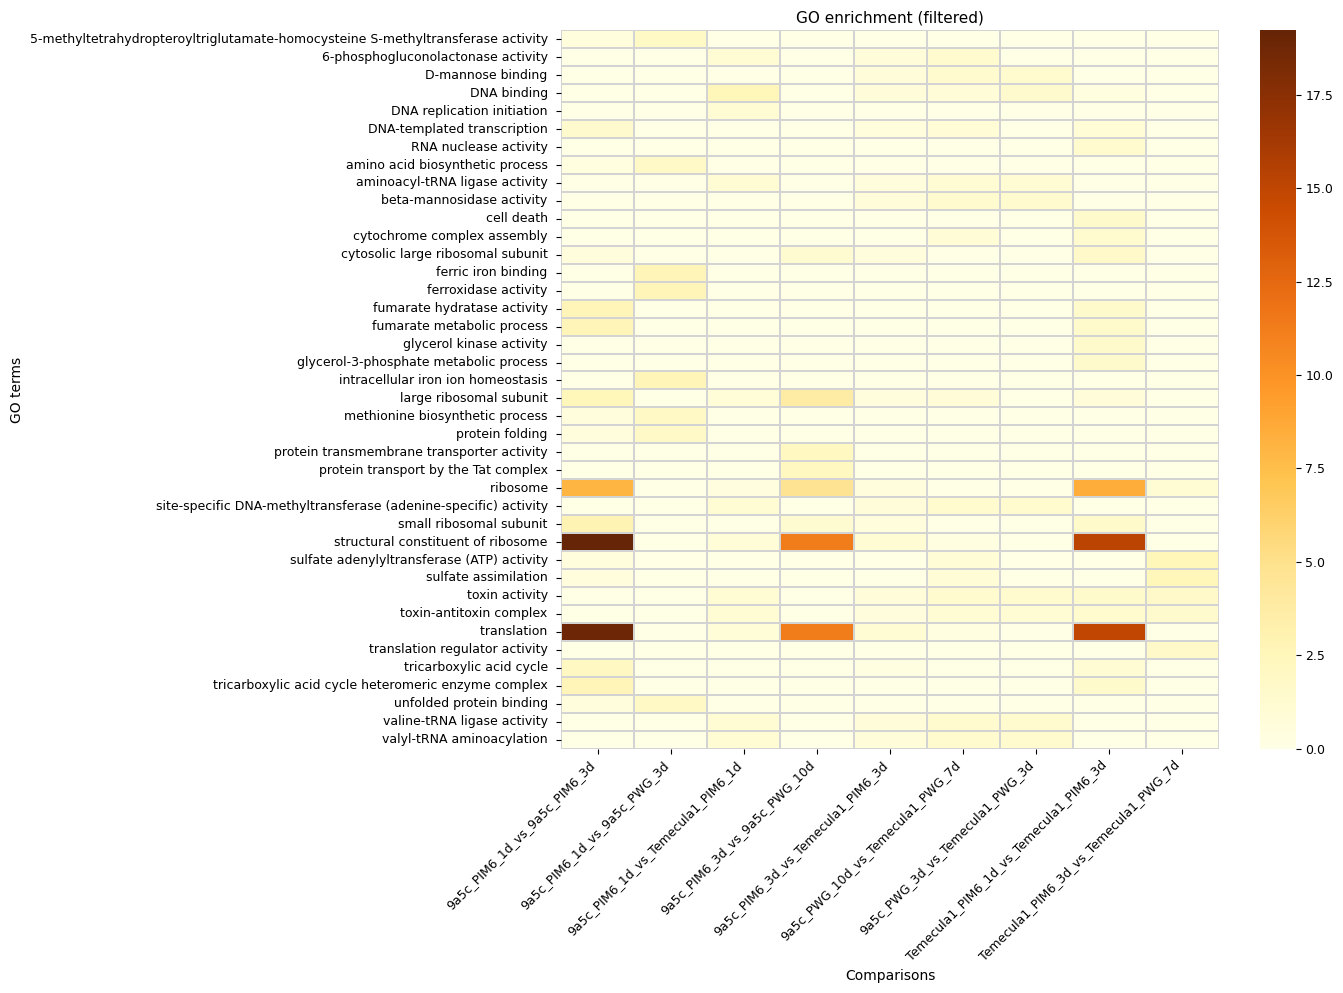

In [38]:
# Cell 13 — Build GO heatmap across all comparisons

# Cell 13 — Build GO heatmap (clean version)

# ---- build matrix from all comparisons ----
go_df = build_go_heatmap_matrix(comparisons)

if go_df.empty:
    print("No GO data found.")
else:
    # ---- clean GO names ----
    go_df["GO"] = go_df["GO"].str.replace(r"\[.*?\]", "", regex=True)

    # ---- rank globally ----
    ranking = (
        go_df.groupby("GO")["score"]
        .mean()
        .sort_values(ascending=False)
        .head(40)
        .index
    )

    go_df = go_df[go_df["GO"].isin(ranking)]

    # ---- pivot to heatmap ----
    heatmap_matrix = go_df.pivot_table(
        index="GO",
        columns="comparison",
        values="score",
        aggfunc="mean"
    ).fillna(0)

    # ---- plot ----
    plt.figure(figsize=(14, 10))

    sns.heatmap(
        heatmap_matrix,
        cmap="YlOrBr",
        linewidths=0.3,
        linecolor="lightgray"
    )

    plt.title("GO enrichment (filtered)")
    plt.xlabel("Comparisons")
    plt.ylabel("GO terms")

    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    plt.savefig("GO_enrichment_heatmap.tiff", dpi=300)
    plt.show()

# # ================================
# # 🔧 USER SETTINGS
# # ================================
# USE_LEVEL2 = True   # set False if you want raw GO terms (not recommended)
# SIGNIFICANCE_THRESHOLD = 0.05
# MAX_COLOR = 6       # cap for -log10(p_adj)
# CMAP = sns.color_palette("YlOrRd", as_cmap=True)

# # ================================
# # 🔹 OPTIONAL: plug your GO level2 mapper here
# # ================================
# def map_to_level2(go_id: str) -> str:
#     try:
#         return get_level2_term(go_id)
#     except Exception:
#         return go_id  # 🔴 TODO: replace with your tool


# # ================================
# # 🔹 BUILD MATRIX
# # ================================
# heatmap_dict = {}

# for rec in tqdm(comparisons, desc="Building GO heatmap"):
#     try:
#         c1 = rec[c1_col]
#         c2 = rec[c2_col]
#         comp_name = f"{c1}_vs_{c2}"

#         comp_out = OUTDIR / comp_name
#         if not comp_out.exists():
#             continue

#         # ---- load GO enrichment ----
#         f1 = find_go_enrichment_file(comp_out, c1)
#         f2 = find_go_enrichment_file(comp_out, c2)

#         df1 = load_go_df(f1)
#         df2 = load_go_df(f2)

#         if df1.empty and df2.empty:
#             continue

#         # ---- rename ----
#         df1 = df1.rename(columns={
#             "fold_enrichment": "fold_enrichment_c1",
#             "p_adj": "p_adj_c1"
#         })

#         df2 = df2.rename(columns={
#             "fold_enrichment": "fold_enrichment_c2",
#             "p_adj": "p_adj_c2"
#         })

#         # ---- merge ----
#         merged = pd.merge(df1, df2, on="go_term", how="outer")

#         # ---- fill ----
#         merged["p_adj_c1"] = pd.to_numeric(merged["p_adj_c1"], errors="coerce").fillna(1.0)
#         merged["p_adj_c2"] = pd.to_numeric(merged["p_adj_c2"], errors="coerce").fillna(1.0)

#         # ---- filter significance ----
#         merged = merged[
#             (merged["p_adj_c1"] <= SIGNIFICANCE_THRESHOLD) |
#             (merged["p_adj_c2"] <= SIGNIFICANCE_THRESHOLD)
#         ]

#         if merged.empty:
#             continue

#         # ---- best p-value ----
#         merged["p_best"] = np.minimum(merged["p_adj_c1"], merged["p_adj_c2"])

#         # ---- score ----
#         merged["score"] = -np.log10(merged["p_best"] + PSEUDO)

#         # ---- map GO level ----
#         if USE_LEVEL2:
#             merged["GO_term"] = merged["go_term"].apply(map_to_level2)
#         else:
#             merged["GO_term"] = merged["go_term"]

#         # ---- aggregate ----
#         agg = (
#             merged.groupby("GO_term")["score"]
#             .max()
#         )

#         heatmap_dict[comp_name] = agg

#     except Exception as e:
#         tqdm.write(f"ERROR in {comp_name}: {e}")


# # ================================
# # 🔹 BUILD FINAL DATAFRAME
# # ================================
# heatmap_df = pd.DataFrame(heatmap_dict).fillna(0)

# # Optional: sort rows by overall importance
# heatmap_df["mean_score"] = heatmap_df.mean(axis=1)
# heatmap_df = heatmap_df.sort_values("mean_score", ascending=False).drop(columns="mean_score")

# print(f"Heatmap shape: {heatmap_df.shape}")


# # ================================
# # 🔹 PLOT HEATMAP
# # ================================
# plt.figure(figsize=(12, max(6, 0.4 * heatmap_df.shape[0])))

# mask = heatmap_df == 0

# sns.heatmap(
#     heatmap_df,
#     cmap=CMAP,
#     mask=mask,
#     linewidths=0.4,
#     linecolor="lightgray",
#     vmin=0,
#     vmax=MAX_COLOR,
#     cbar_kws={"label": "-log10(adjusted p-value)"}
# )

# plt.xticks(rotation=45, ha="right")
# plt.yticks(fontsize=9)

# plt.title("GO enrichment across comparisons", fontsize=12)

# plt.tight_layout()

# # Save
# out_path = OUTDIR / "GO_heatmap.tiff"
# plt.savefig(out_path, dpi=600, bbox_inches="tight")

# plt.show()

# print(f"Saved heatmap to: {out_path}")